# Retention-time alignment — demo

Demonstrates `Handler.align_chromatograms`, which corrects per-trace retention-time drift in place. The method takes a single retention-time window `[lower_rt, upper_rt]` containing a reference peak shared by all traces, finds the per-trace shift that best aligns the signal inside that window against the trace-wise mean template, and mutates each chromatogram's `time` array (and every `Peak.location`) by the recovered `delta_rt`.

Here we use the ASM kinetic-series fixture and align on a peak in the 6.5–8.1 min range.

## 1. Load the kinetic series

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from chromhandler.handler import Handler

ASM_DIR = Path.cwd().parent / "tests" / "fixtures" / "asm_kinetic_series"
handler = Handler.read_asm(path=ASM_DIR, mode="timecourse")

chroms = [c for s in handler.samples for c in s.chromatograms]
trace_ids = [f"{s.id}/{c.id}" for s in handler.samples for c in s.chromatograms]
print(f"loaded {len(chroms)} chromatogram(s); time range {chroms[0].time[0]:.2f}–{chroms[0].time[-1]:.2f} min")

loaded 7 chromatogram(s); time range 0.00–20.00 min


## 2. Plot helper

We'll plot the alignment window before and after `align_chromatograms` runs. To make the misalignment visible we use a tight x-range around the chosen window.

In [2]:
LOWER_RT, UPPER_RT = 6.5, 8.1


def show(handler, title):
    fig, _ = handler.plot(overlay="all", ax_size=(9.0, 4.0))
    ax = fig.axes[0]
    ax.axvspan(LOWER_RT, UPPER_RT, alpha=0.1, color="orange", label="alignment window")
    ax.set_xlim(LOWER_RT - 0.2, UPPER_RT + 0.2)
    ax.set_title(title)
    ax.legend(loc="upper right", fontsize=8, ncol=2)
    fig.tight_layout()
    return fig


## 3. Before alignment

Trace-to-trace retention-time drift shows up as horizontal displacement of the peaks across traces inside the orange window.

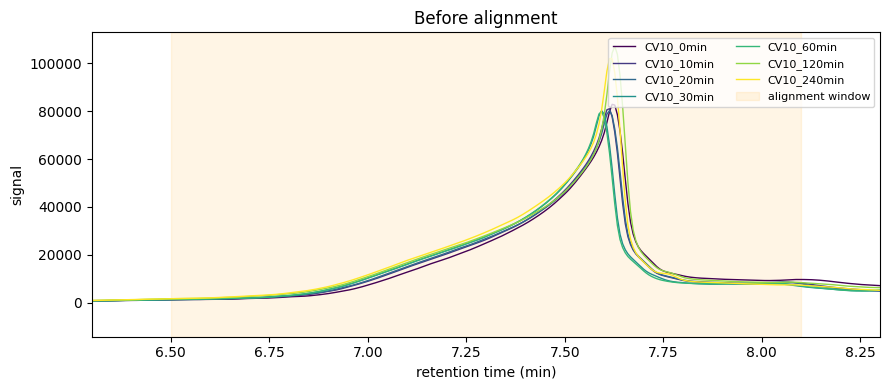

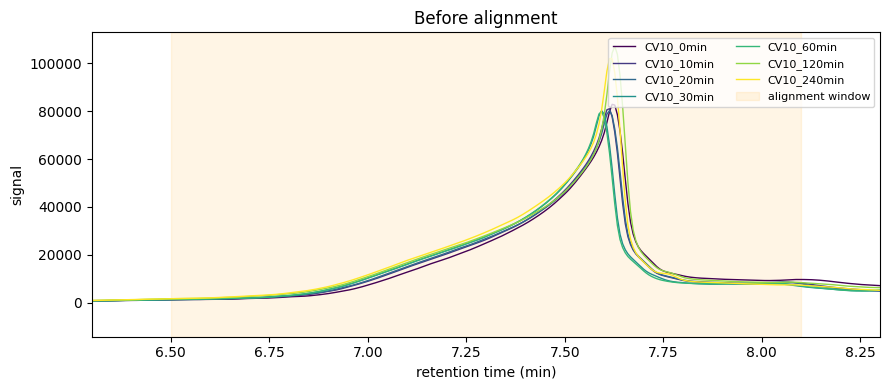

In [3]:
fig_before = show(handler, title="Before alignment")
fig_before


## 4. Align

`Handler.align_chromatograms` resamples all traces onto a common time grid, cross-correlates the signal inside `[lower_rt, upper_rt]` against the mean template to get a coarse integer-sample shift, refines each shift with multi-start Adam, and finally mutates each chromatogram's `time` and `Peak.location` in place. The returned `AlignmentResult` carries the raw sample-index shifts, their RT equivalents, the common `dt`, and the pre/post optimization loss.

In [4]:
result = handler.align_chromatograms(
    lower_rt=LOWER_RT,
    upper_rt=UPPER_RT,
    max_shift_rt=0.5,
)

print(f"dt           = {result.dt:.5f} min")
print(f"loss initial = {result.loss_initial:.4g}")
print(f"loss final   = {result.loss_final:.4g}")
print()
print("per-trace shifts:")
print(f"  {'trace_id':<32s}  {'samples':>10s}  {'Δrt (min)':>12s}")
for tid, n_samp, drt in zip(result.trace_ids, result.shifts_samples, result.delta_rt):
    print(f"  {tid:<32s}  {n_samp:>10.3f}  {drt:>12.4f}")

/Users/max/code/Chromhandler/chromhandler/fitting/shift.py:141: RuntimeWarning: Mean of empty slice
  template = np.nanmean(np.where(mask_arr, signal, np.nan), axis=0)


dt           = 0.00667 min
loss initial = 5.64e+10
loss final   = 6.388e+09

per-trace shifts:
  trace_id                             samples     Δrt (min)
  CV10/CV10_0min                        -2.000       -0.0133
  CV10/CV10_10min                       -0.004       -0.0000
  CV10/CV10_20min                       -0.244       -0.0016
  CV10/CV10_30min                        2.577        0.0172
  CV10/CV10_60min                        2.944        0.0196
  CV10/CV10_120min                      -2.497       -0.0166
  CV10/CV10_240min                      -0.776       -0.0052


## 5. After alignment

Peaks inside the orange window should now line up vertically across all traces.

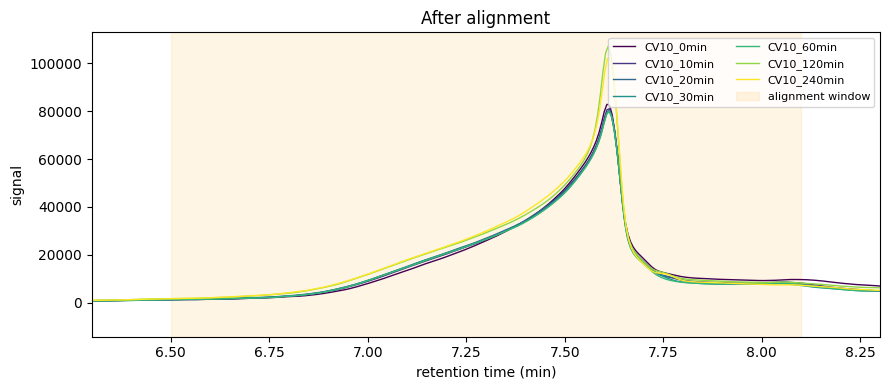

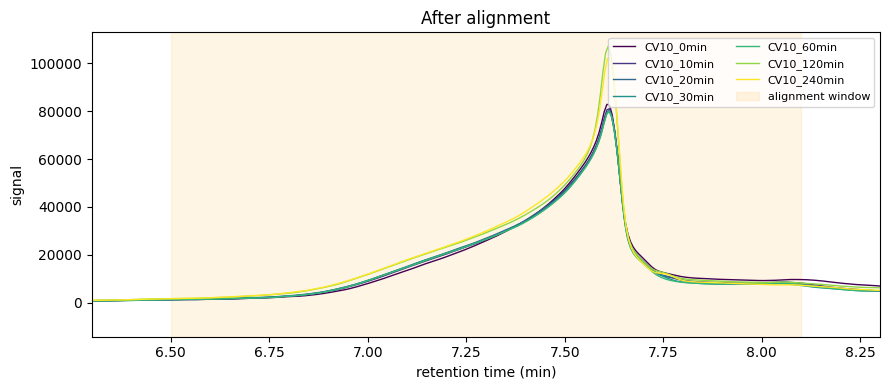

In [5]:
fig_after = show(handler, title="After alignment")
fig_after


## 6. Full retention-time view

The same shifts apply uniformly across each trace (alignment is a single offset per chromatogram, not a stretch), so all peaks — not just the one used for alignment — are now consistent in retention time.

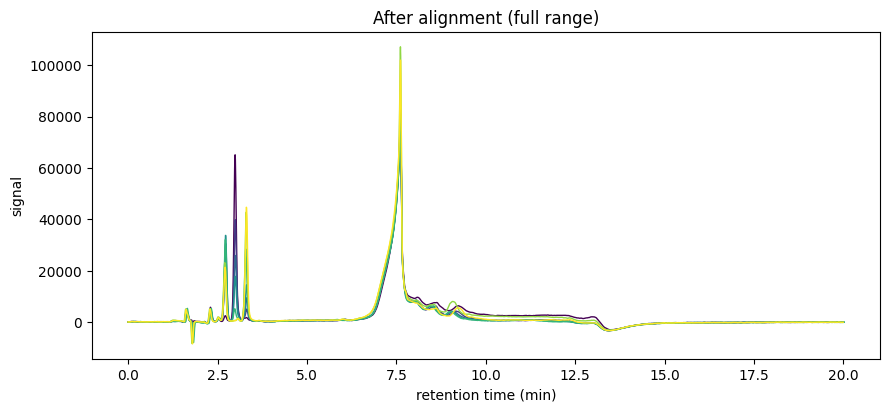

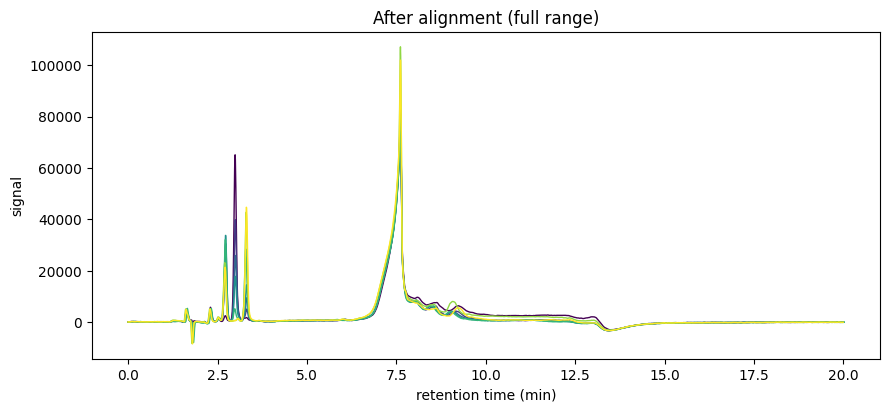

In [6]:
fig_wide, _ = handler.plot(overlay="all", ax_size=(9.0, 4.0))
fig_wide.axes[0].set_title("After alignment (full range)")
fig_wide
